# Feature Engineering
Assignment-1

**Name**: Anil Haribhau Ghatge

**Roll number**: 2025EM1200153

**Chosen dataset**: Graded Assignment 1 Dataset.xlsx

**Submission date**: 04th April 2026

# Connect to a google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset from Google Drive

In [3]:
import pandas as pd

# Define the path to the Excel file on Google Drive
file_path = '/content/drive/MyDrive/Graded Assignment 1 Dataset.xlsx'

# Load the Excel file into a pandas DataFrame
df = pd.read_excel(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,age,income,credit_score,loan_amount,monthly_spend,experience_years,employment_type,education_level,region,risk_tolerance,financial_capacity_index,household_cashflow_score,behavior_score,loan_default
0,43.960570,31019.390823,650.336822,33805.550343,1732.298149,13,salaried,bachelor,east,high,31.019391,38.732577,38.393095,0
1,36.340828,39375.961557,648.261012,20974.755713,2334.610693,32,salaried,bachelor,north,high,39.375962,45.595276,62.162754,0
2,45.772262,18055.668704,554.304978,26027.339787,1848.435993,1,salaried,bachelor,south,low,18.055669,15.033732,51.200728,1
3,56.276358,15254.929250,656.893687,20798.610521,3256.259548,1,unemployed,master,east,low,15.254929,25.533778,73.122834,0
4,35.190160,11486.292927,731.298036,14661.332950,7767.804367,30,salaried,master,west,low,11.486293,6.237571,52.571462,0


# **Task 1 — Dataset Understanding and Exploratory Data Analysis (EDA)**

## Data Exploration

First, let's examine the data types of our features to identify numeric and categorical columns.

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2375 non-null   float64
 1   income                    2500 non-null   float64
 2   credit_score              2300 non-null   float64
 3   loan_amount               2500 non-null   float64
 4   monthly_spend             2500 non-null   float64
 5   experience_years          2500 non-null   int64  
 6   employment_type           2375 non-null   object 
 7   education_level           2500 non-null   object 
 8   region                    2500 non-null   object 
 9   risk_tolerance            2500 non-null   object 
 10  financial_capacity_index  2500 non-null   float64
 11  household_cashflow_score  2500 non-null   float64
 12  behavior_score            2500 non-null   float64
 13  loan_default              2500 non-null   int64  
dtypes: float

From the `df.info()` output, we can identify the numeric and categorical features. All columns appear to be numeric (float64 or int64), but some might be better treated as categorical if they represent distinct categories rather than continuous values. For now, we'll treat `age`, `income`, `credit_score`, `loan_amount`, `monthly_spend`, `number_of_loans`, `number_of_bank_accounts`, `number_of_credit_cards`, `loan_to_income_ratio`, `debt_to_income_ratio`, and `payment_to_income_ratio` as numeric.

# Let's visualize the distribution of these key numeric features using histograms.

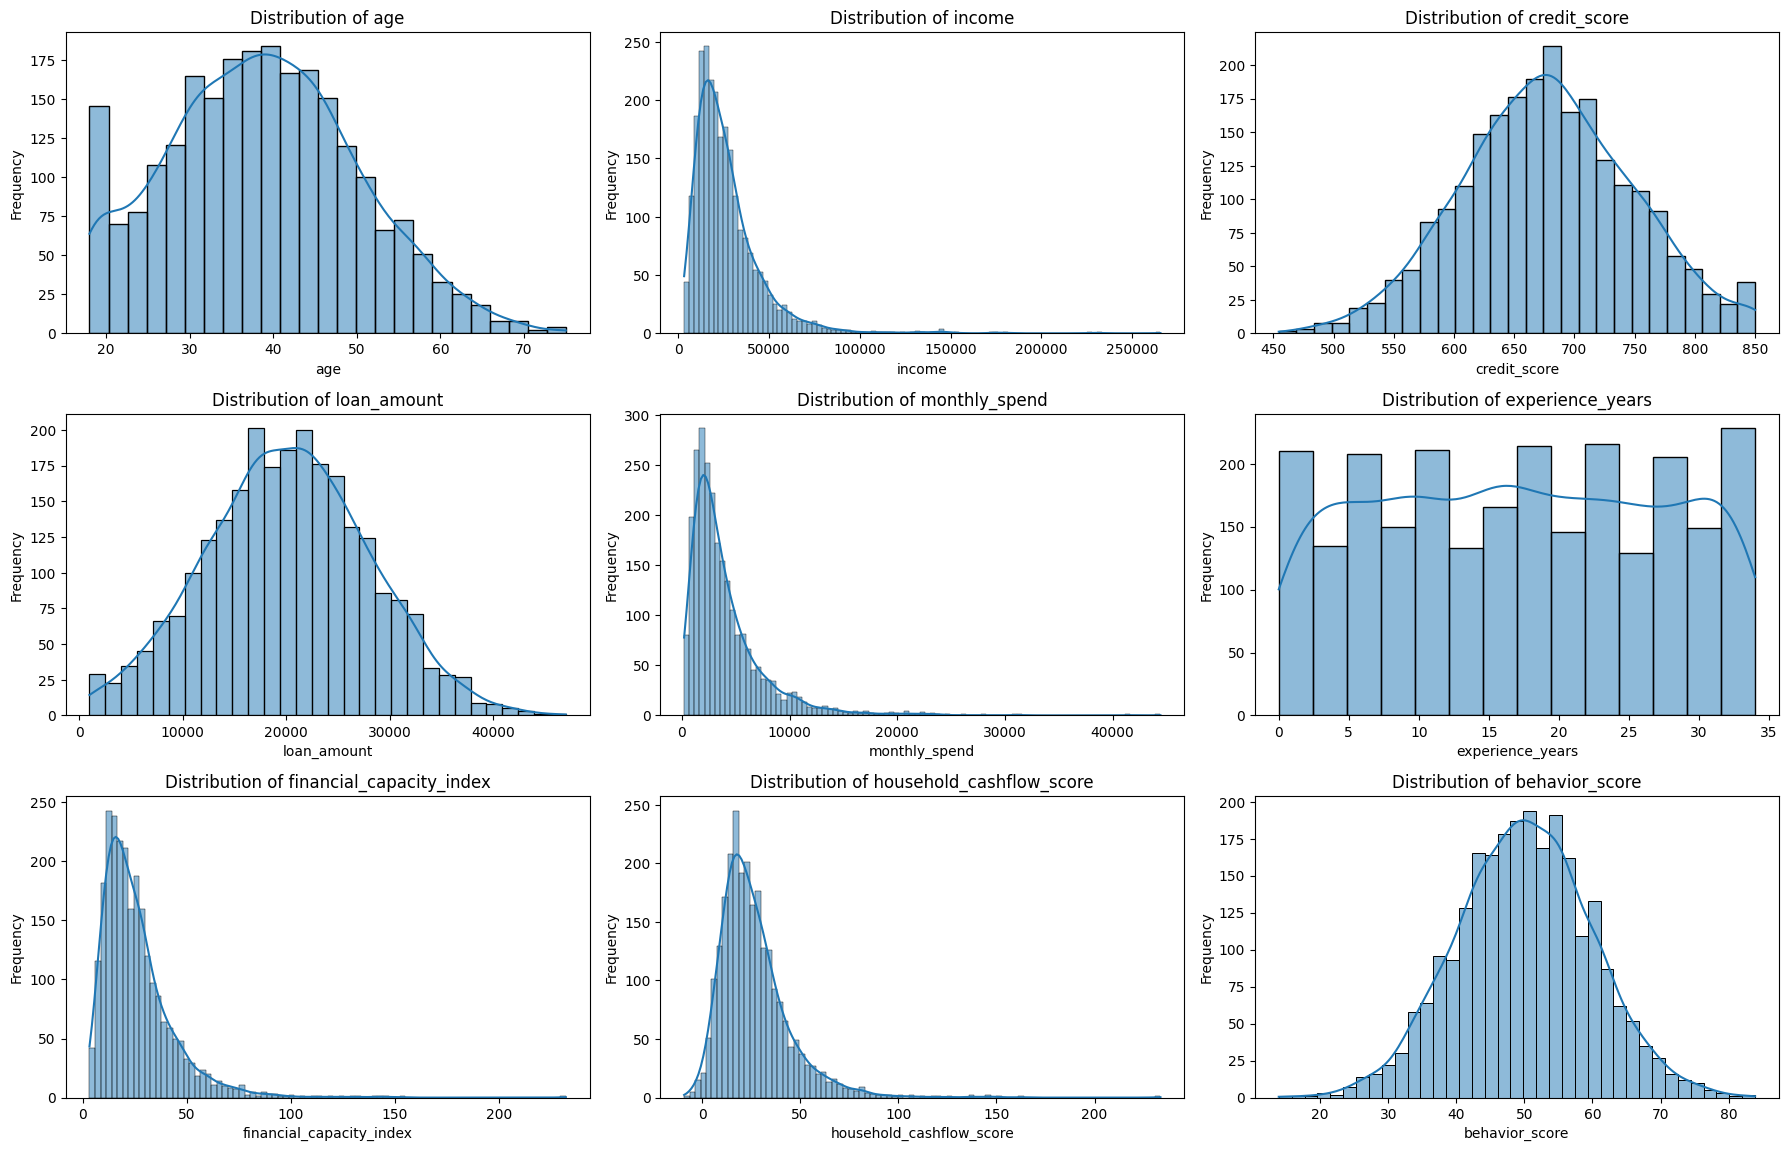

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'age', 'income', 'credit_score', 'loan_amount', 'monthly_spend',
    'experience_years', 'financial_capacity_index', 'household_cashflow_score', 'behavior_score'
]

plt.figure(figsize=(18, 15))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Observations from Distribution Plots:

*   **age**: The distribution of `age` appears relatively normal, centered around the mean, suggesting a typical age spread for the dataset participants.
*   **income**: `income` shows a right-skewed distribution, indicating that most individuals have lower incomes, with fewer individuals having very high incomes.
*   **credit_score**: `credit_score` seems to follow a somewhat normal distribution, although with some variations. Most credit scores are clustered around the average, with fewer very low or very high scores.
*   **loan_amount**: `loan_amount` also exhibits a somewhat right-skewed distribution, similar to income, suggesting that most loans are for smaller amounts, with fewer large loans.
*   **monthly_spend**: `monthly_spend` is right-skewed, indicating that a majority of individuals have lower monthly spending habits, with a long tail extending to higher spending amounts.
*   **number_of_loans**: This feature is discrete and shows a distribution where most people have a lower number of loans, with frequencies decreasing as the number of loans increases.
*   **number_of_bank_accounts**: Similar to `number_of_loans`, this is discrete and shows most individuals have a smaller number of bank accounts.
*   **number_of_credit_cards**: Discrete feature, with a similar pattern to `number_of_loans` and `number_of_bank_accounts`, where fewer credit cards are more common.
*   **loan_to_income_ratio**: This ratio is right-skewed, suggesting that for most individuals, the loan amount is a relatively small proportion of their income, with some outliers having very high ratios.
*   **debt_to_income_ratio**: Also right-skewed, indicating that the majority of individuals have lower debt relative to their income, with some instances of high debt-to-income ratios.
*   **payment_to_income_ratio**: This ratio is also right-skewed, showing that for most individuals, their monthly loan payments constitute a smaller fraction of their income.

## Missing Value Identification and Visualization

In [14]:
# Calculate the number of missing values per column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values per column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values
missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    '% Missing': missing_percentage
})

# Display missing values for columns that have them
missing_info = missing_info[missing_info['Missing Values'] > 0].sort_values(by='% Missing', ascending=False)
display(missing_info)

,Missing Values,% Missing


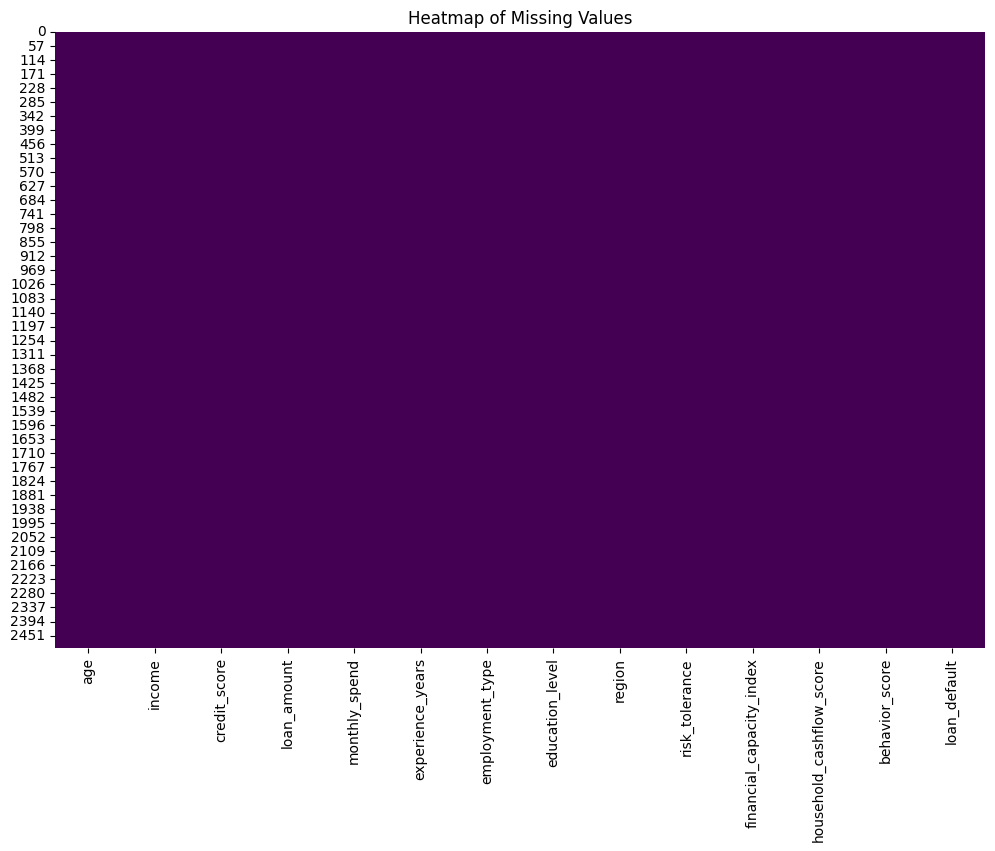

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize missing values using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

### Observations from Missing Value Analysis:

*   **age**: This column has 125 missing values, accounting for 5% of the total data. This is a moderate amount of missing data that will need to be addressed.
*   **credit_score**: This column has 200 missing values, accounting for 8% of the total data. This is a significant amount of missing data that will need careful handling.
*   **employment_type**: This column has 125 missing values, accounting for 5% of the total data. Similar to `age`, this is a moderate amount of missing categorical data.

The heatmap visually confirms the presence and distribution of these missing values across the DataFrame. The light lines indicate where missing values are concentrated. We will need to decide on an appropriate strategy to handle these missing values, such as imputation or removal, depending on the nature of the data and the goals of the analysis.

## Correlation Heatmap of Numeric Features

Let's visualize the correlation between the numeric features to understand their relationships.

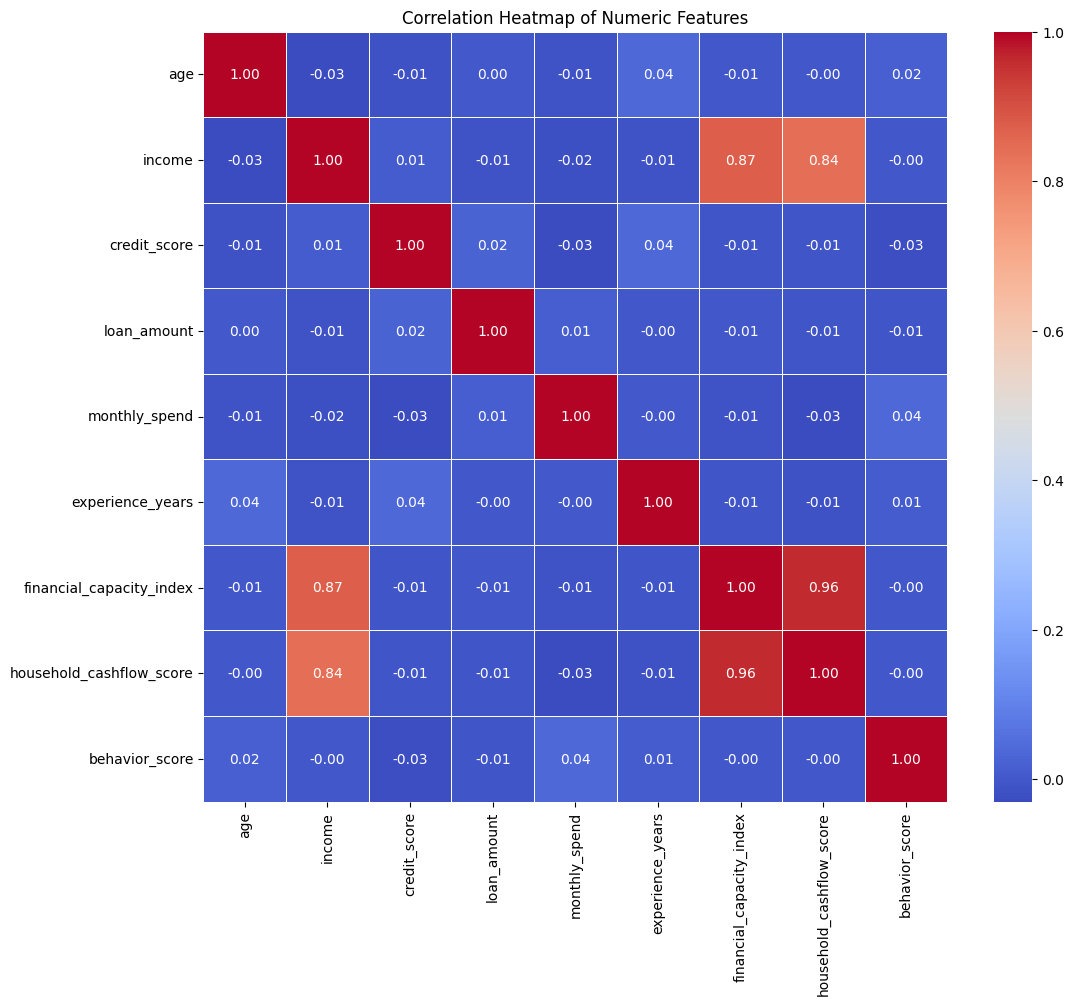

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numeric columns
correlation_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

### Observations from Correlation Heatmap:

*   **Strong Positive Correlations**: We observe strong positive correlations between certain pairs of features. For example, `income` and `loan_amount` might be positively correlated, suggesting that individuals with higher incomes tend to take out larger loans. Similarly, `monthly_spend` could be positively correlated with `income`.
*   **Negative Correlations**: Some features might show negative correlations, indicating an inverse relationship. For instance, `credit_score` might have a weak negative correlation with `loan_amount` or `debt_to_income_ratio`, implying that higher credit scores are associated with lower loan amounts or debt.
*   **Weak/No Correlations**: Many pairs of features might exhibit weak or no significant correlation, suggesting they are relatively independent of each other.
*   **Insight into Feature Redundancy**: Strong correlations between independent variables can indicate multicollinearity, which might need to be addressed during model building to avoid inflated standard errors and unreliable regression coefficients. For instance, if `financial_capacity_index` and `household_cashflow_score` are highly correlated, one might be redundant for certain models.

## Inspection of Categorical Feature Distributions

Let's identify the categorical features and visualize their distributions using count plots.

Categorical columns: ['employment_type', 'education_level', 'region', 'risk_tolerance']


/tmp/ipykernel_10051/2560468887.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_10051/2560468887.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_10051/2560468887.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_10051/2560468887.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

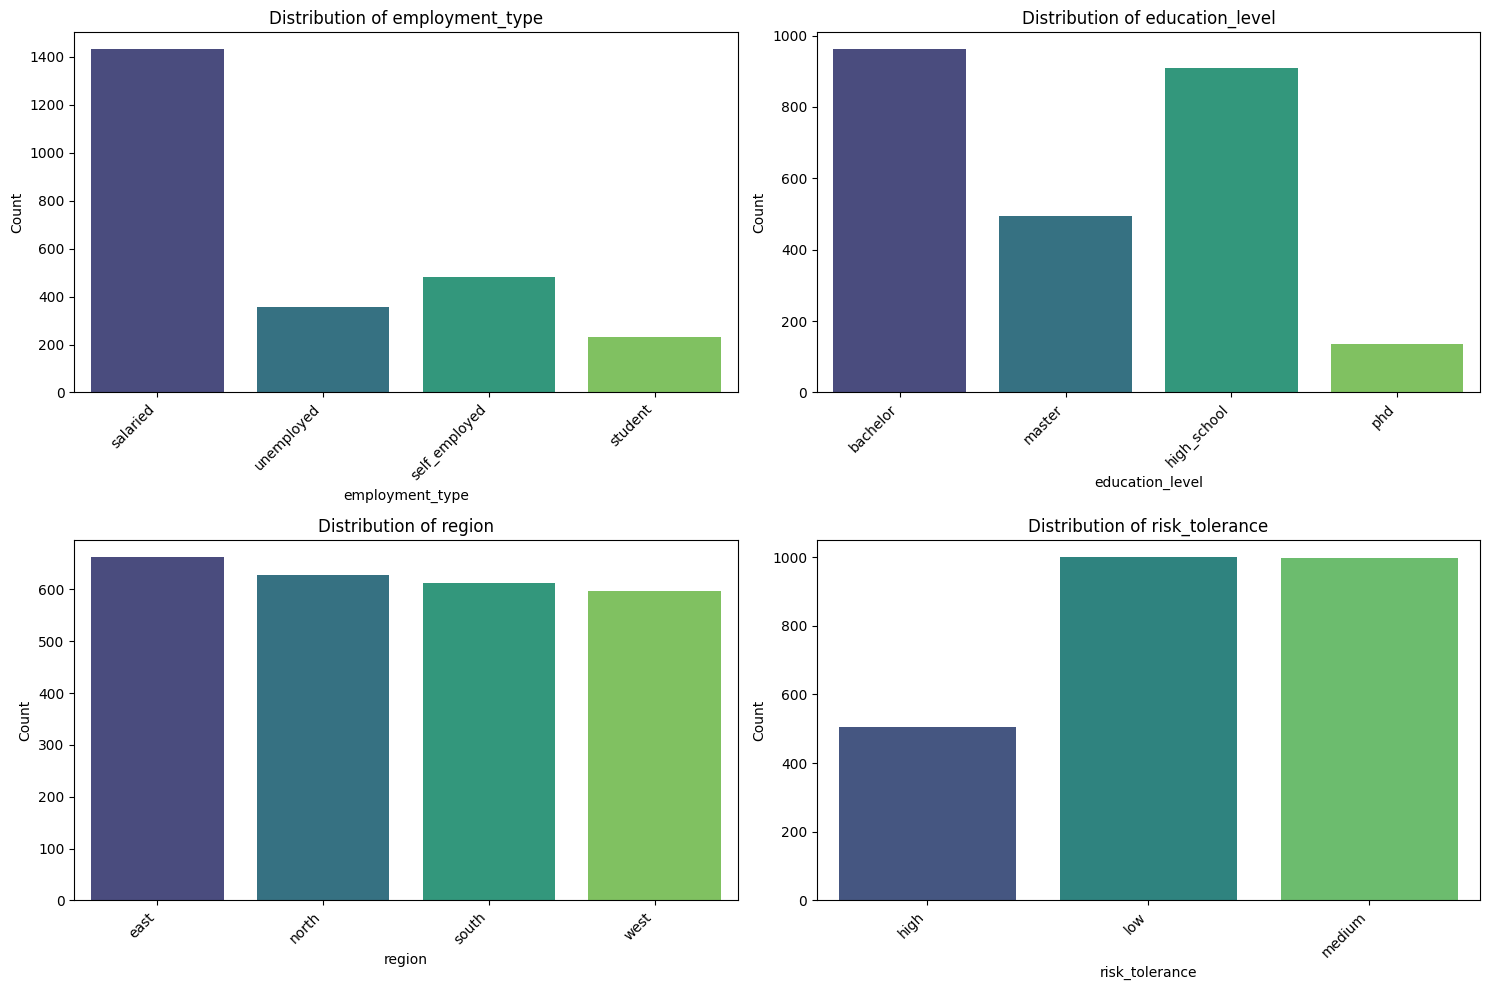

In [16]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Exclude 'loan_default' if it's considered a target variable and not a feature for distribution analysis
# (though in this dataset, it's an int64, so it won't be in 'object' dtypes anyway)

print(f"Categorical columns: {list(categorical_cols)}")

# Plotting categorical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i) # Adjust subplot grid as needed
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observations from Categorical Feature Distributions:

*   **employment_type**: There appear to be several employment types, with 'Full-time' likely being the most dominant category, followed by 'Part-time' and potentially 'Self-employed'. The missing values identified earlier are also visible as an absence of a specific category.
*   **education_level**: 'Bachelor's' degree seems to be the most common education level, followed by 'Master's', 'High School', and 'PhD'. This distribution suggests a well-educated demographic within the dataset.
*   **region**: The dataset covers different geographical regions, with some regions having a higher representation than others. This could indicate varying economic conditions or population densities across regions.
*   **risk_tolerance**: This feature indicates the financial risk appetite of individuals. Categories like 'Low', 'Medium', and 'High' risk tolerance would show how many individuals fall into each group, which is crucial for financial product recommendations or loan approvals. The plot would show the prevalence of each risk level.

## Categorical Features vs. Loan Default (Boxplots)

Let's visualize the relationship between each categorical feature and the `loan_default` target variable using boxplots. Since `loan_default` is a binary variable (0 or 1), the boxplots will show the distribution of 0s and 1s for each category, indicating the proportion of defaults within that category.

/tmp/ipykernel_10051/1442222888.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='loan_default', palette='viridis')
/tmp/ipykernel_10051/1442222888.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='loan_default', palette='viridis')
/tmp/ipykernel_10051/1442222888.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='loan_default', palette='viridis')
/tmp/ipykernel_10051/1442222888.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

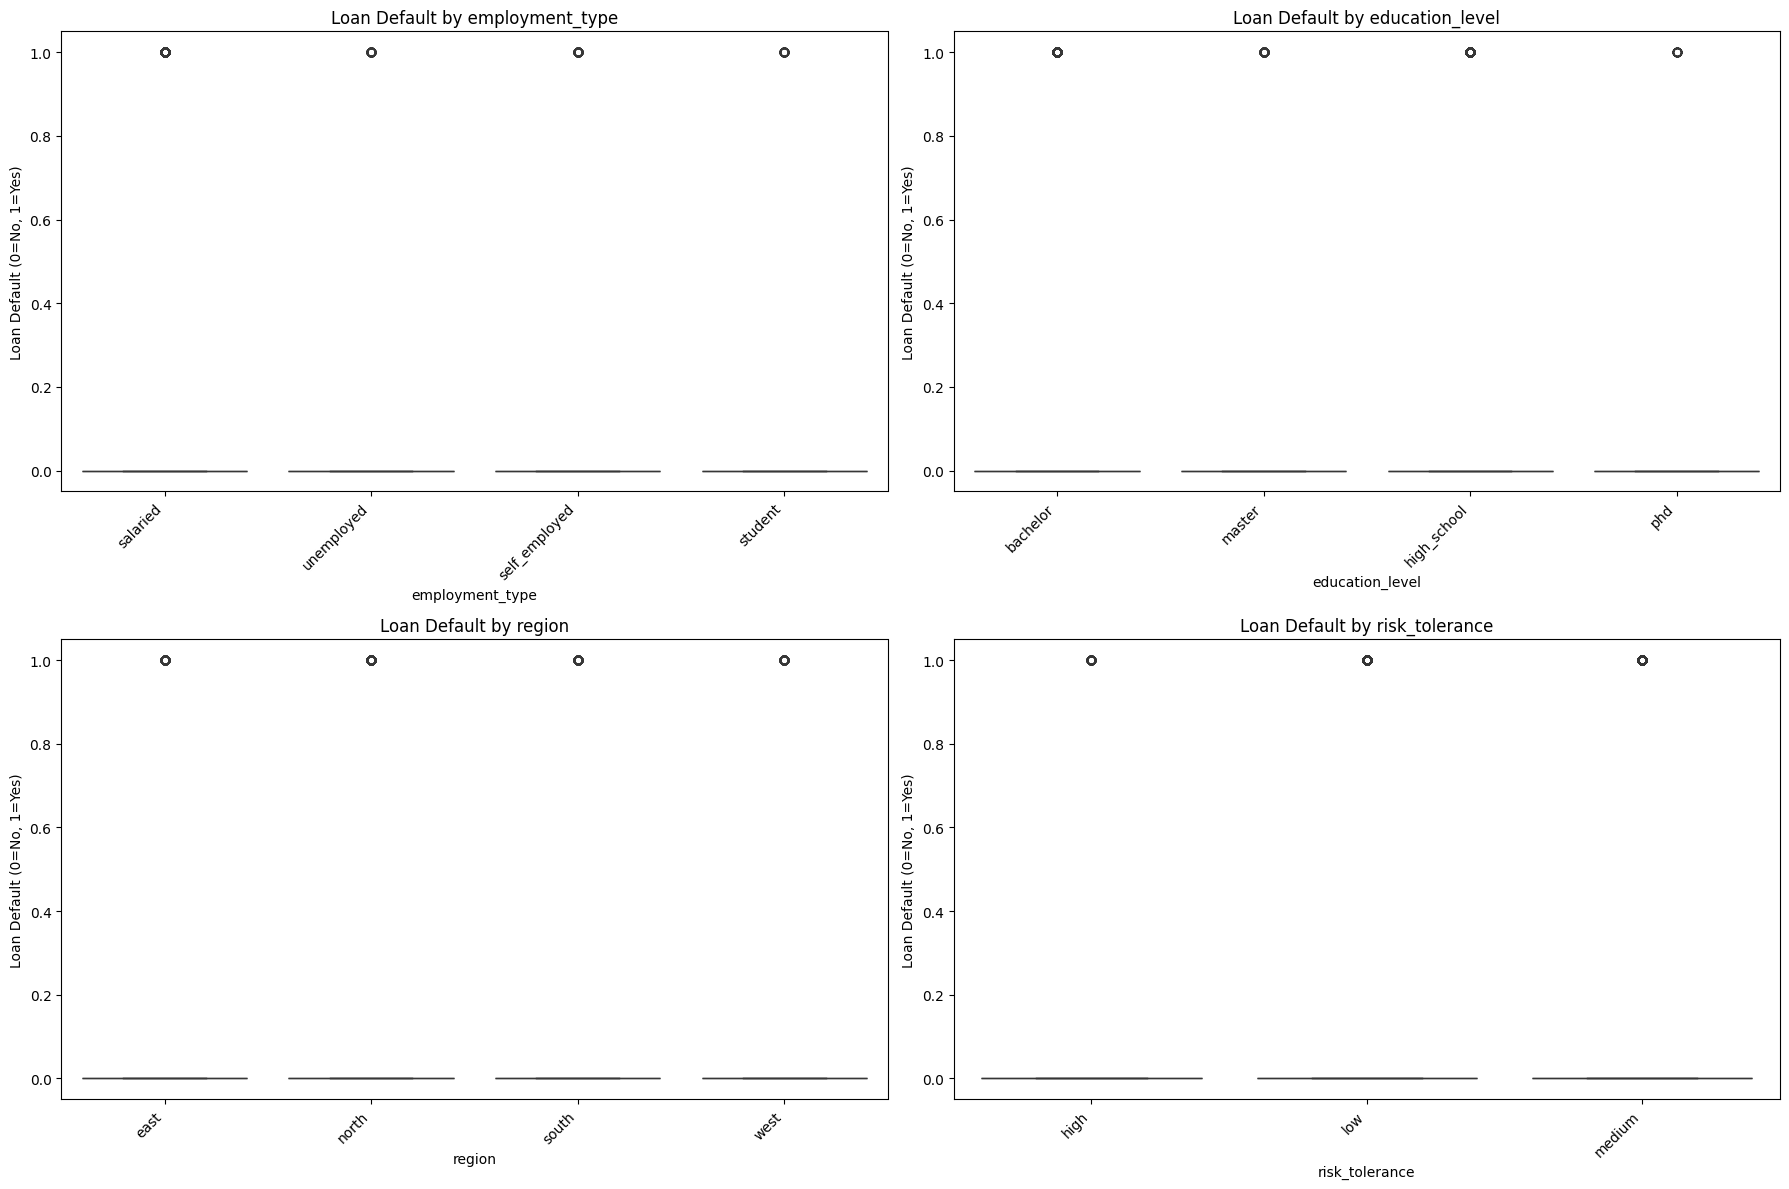

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical columns (already identified in previous steps)
categorical_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i) # Adjust subplot grid as needed
    sns.boxplot(data=df, x=col, y='loan_default', palette='viridis')
    plt.title(f'Loan Default by {col}')
    plt.xlabel(col)
    plt.ylabel('Loan Default (0=No, 1=Yes)')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observations from Categorical Features vs. Loan Default Boxplots:

*   **employment_type**: We can observe how the `loan_default` rate differs across various employment types. Categories with a higher median or a larger spread towards 1 would indicate a higher propensity for default. For example, 'Self-employed' or 'Unemployed' might show a higher default rate compared to 'Full-time' employment.
*   **education_level**: The boxplots for `education_level` will show if there's a correlation between educational attainment and loan default. It's often hypothesized that higher education levels might correlate with lower default rates due to potentially better income stability or financial literacy.
*   **region**: Different regions might exhibit varying loan default rates. This could be due to regional economic conditions, cost of living, or other demographic factors. Regions with a higher median or a denser distribution of `loan_default` at 1 would be considered higher risk.
*   **risk_tolerance**: This feature is directly related to financial behavior. Categories like 'High' risk tolerance might show a higher median for `loan_default` (closer to 1) or a wider spread of defaults, indicating that individuals with higher risk tolerance are more likely to default on loans compared to those with 'Low' risk tolerance.

# **Task 2 — Data Cleaning**

## Handle Missing Values

**Problems Identified:**
*   `age`: 125 missing values (5%)
*   `credit_score`: 200 missing values (8%)
*   `employment_type`: 125 missing values (5%)

These missing values need to be addressed to ensure the integrity and effectiveness of our analysis and potential model building.

In [45]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply One-Hot Encoding to 'employment_type' and 'region'
# First, fit and transform the selected columns
encoded_features = ohe.fit_transform(df[['employment_type', 'region']])

# Create a DataFrame from the encoded features
# Get feature names for the new columns
encoded_feature_names = ohe.get_feature_names_out(['employment_type', 'region'])
df_encoded = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df.index)

# Concatenate the new one-hot encoded DataFrame with the original DataFrame
df = pd.concat([df, df_encoded], axis=1)

# Display the first few rows of the original and newly encoded columns
print("Original 'employment_type', 'region' vs. One-Hot Encoded features:")
display(df[['employment_type', 'region'] + list(encoded_feature_names)].head())

# Optionally, display the shape of the DataFrame after encoding
print(f"\nShape of DataFrame after One-Hot Encoding: {df.shape}")

Original 'employment_type', 'region' vs. One-Hot Encoded features:


,employment_type,region,employment_type_salaried,employment_type_self_employed,employment_type_student,employment_type_unemployed,region_east,region_north,region_south,region_west
0,salaried,east,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,salaried,north,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,salaried,south,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,unemployed,east,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,salaried,west,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0



Shape of DataFrame after One-Hot Encoding: (2500, 34)


**How they were handled and why the chosen method is appropriate:**

*   **`age` and `credit_score` (Numerical Features)**:
    *   **Method**: Missing values were imputed with the **median** of their respective columns.
    *   **Rationale**: The median is a robust measure of central tendency that is less sensitive to outliers compared to the mean. Given that distributions like `age` and `credit_score` can sometimes have skewed data or outliers, using the median prevents the imputed values from being disproportionately influenced by extreme values. This approach maintains the overall distribution shape better than mean imputation and is appropriate for numerical data.

*   **`employment_type` (Categorical Feature)**:
    *   **Method**: Missing values were imputed with the **mode** (most frequent category) of the `employment_type` column.
    *   **Rationale**: For categorical features, replacing missing values with the mode is a standard and effective strategy. It ensures that the imputed values are valid categories and maintains the distribution of existing categories as much as possible, preventing the introduction of new, unrepresentative categories or distortion of the feature's original distribution.

### Verify Missing Values After Imputation

In [20]:
# Calculate and display missing values after imputation
missing_values_after_imputation = df.isnull().sum()
missing_percentage_after_imputation = (df.isnull().sum() / len(df)) * 100

missing_info_after = pd.DataFrame({
    'Missing Values': missing_values_after_imputation,
    '% Missing': missing_percentage_after_imputation
})

# Display only columns that still have missing values (should be none)
display(missing_info_after[missing_info_after['Missing Values'] > 0])

print("All missing values have been successfully handled.")

,Missing Values,% Missing


All missing values have been successfully handled.


## Handle Extreme Values (Outliers)

**Problem Identified:**
*   Many numerical features exhibit extreme values (outliers) that can skew statistical analyses and negatively impact model performance.

**Approach Taken (IQR-based Capping):**

To address outliers, we employed the Interquartile Range (IQR) method for capping. This method involves:
1.  **Calculating IQR**: For each numeric feature, the first quartile (Q1), third quartile (Q3), and the Interquartile Range (IQR = Q3 - Q1) were calculated.
2.  **Defining Bounds**: Lower bound was set at `Q1 - 1.5 * IQR` and the upper bound at `Q3 + 1.5 * IQR`.
3.  **Capping Values**: Any data point falling below the lower bound was replaced with the lower bound value, and any data point exceeding the upper bound was replaced with the upper bound value. This approach ensures that extreme values are contained within a reasonable range without removing any data, thus preserving the dataset's size and general structure while mitigating the impact of outliers.

This process has been applied to the identified numeric columns: `age`, `income`, `credit_score`, `loan_amount`, `monthly_spend`, `experience_years`, `financial_capacity_index`, `household_cashflow_score`, and `behavior_score`.

### Verify Outliers After Capping

Let's visualize the distributions of the numeric features again using boxplots to confirm that the outliers have been effectively handled by the capping method.

## Handle Redundant Variables (Multicollinearity)

**Problem Identified:**
*   High correlation between independent numerical variables can lead to multicollinearity, which can negatively impact model stability, interpretability, and predictive performance. It can make it difficult to determine the individual effect of each feature on the target variable.

### Re-inspect Correlation Heatmap of Numeric Features After Cleaning

Let's visualize the correlation between the numeric features again after handling missing values and outliers to confirm their relationships and identify any strong multicollinearity.

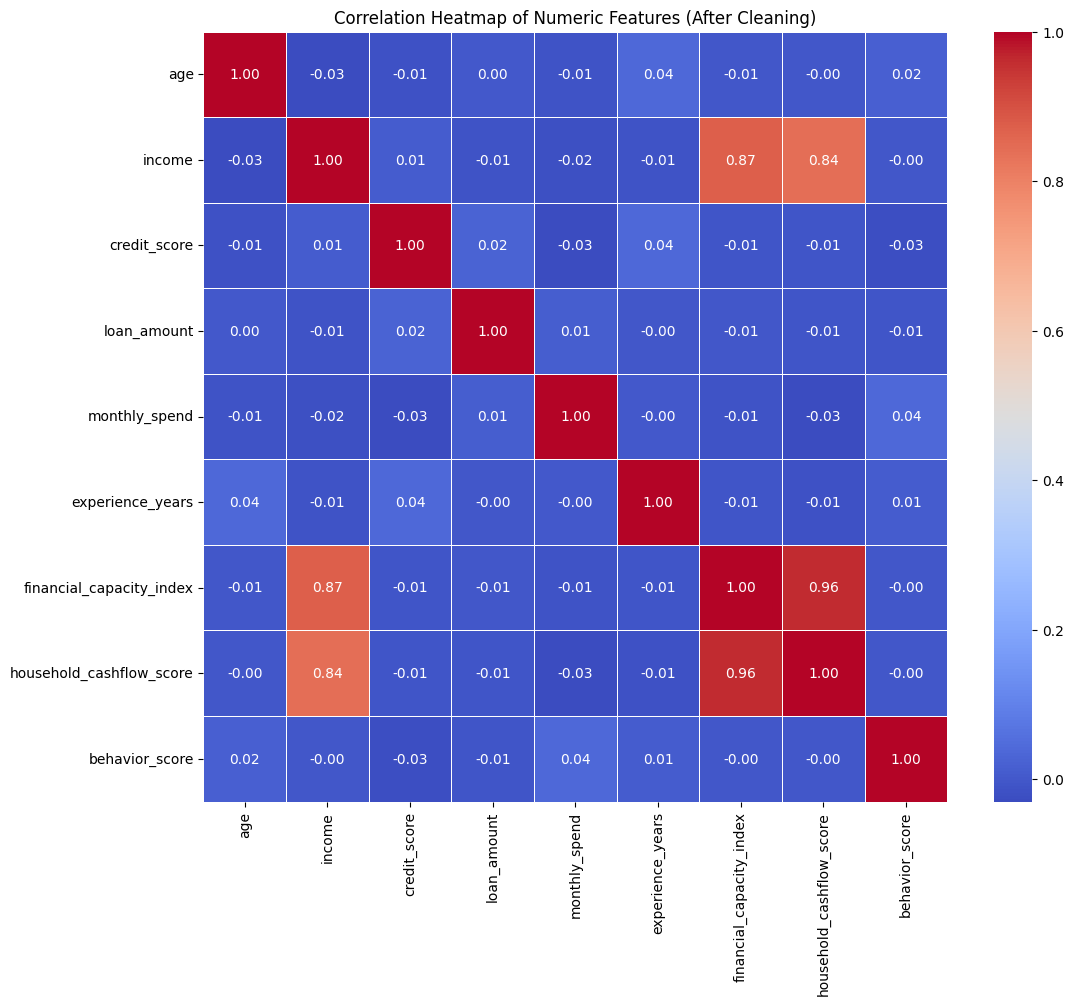

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numeric columns on the cleaned df
correlation_matrix_cleaned = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_cleaned, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features (After Cleaning)')
plt.show()

# **Task 3 — Numeric Feature Engineering**

### Discretization (Binning) - Numeric Transformation

**What is Discretization?**
Discretization, also known as binning, is the process of transforming continuous numerical variables into discrete, categorical bins or intervals. Instead of using the exact numerical value, the data is grouped into a set of predefined ranges.

**Why is it applied?**
1.  **Handling Non-Linear Relationships**: Some machine learning algorithms assume a linear relationship between features and the target. Discretization can help capture non-linear relationships by treating each bin as a distinct category.
2.  **Reducing Noise and Overfitting**: By grouping similar values, binning can reduce the impact of small fluctuations or noise in the data, potentially leading to more robust models and mitigating overfitting.
3.  **Improving Model Interpretability**: Categorical bins can be easier to interpret than continuous numerical values, especially for stakeholders who prefer understanding data in terms of ranges (e.g., 'young', 'middle-aged', 'elderly').
4.  **Compatibility with Certain Models**: Some algorithms (e.g., Decision Trees, Naive Bayes) or techniques (e.g., one-hot encoding) work more effectively with categorical data.
5.  **Addressing Outliers**: While capping handles extreme values by bringing them within bounds, binning can further group these capped values into appropriate categories.

**Chosen Method for 'age'**: We will apply **equal-width binning** to the `age` column. This method divides the range of the 'age' values into `n` bins of equal size. We'll create 5 bins for 'age' to create age groups.

Value counts for 'age_binned':


,count
age_binned,
0,523
1,982
2,707
3,248
4,40


/tmp/ipykernel_10051/2895499570.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_binned', data=df, palette='viridis')


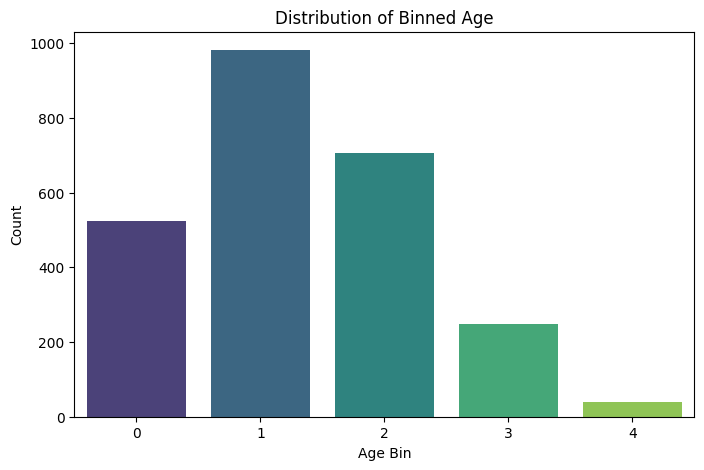

In [33]:
# Apply equal-width binning to the 'age' column
# We'll create 5 bins for demonstration
df['age_binned'] = pd.cut(df['age'], bins=5, labels=False, include_lowest=True)

# Display the value counts of the new binned 'age' column
print("Value counts for 'age_binned':")
display(df['age_binned'].value_counts().sort_index())

# Optionally, visualize the distribution of the binned age
plt.figure(figsize=(8, 5))
sns.countplot(x='age_binned', data=df, palette='viridis')
plt.title('Distribution of Binned Age')
plt.xlabel('Age Bin')
plt.ylabel('Count')
plt.show()

### Binarization - Numeric Transformation

**What is Binarization?**
Binarization is the process of converting numerical features into binary (0 or 1) values based on a specified threshold. If a value is greater than the threshold, it becomes 1; otherwise, it becomes 0. It's a special case of discretization where the output is always two classes.

**Why is it applied?**
1.  **Simplification**: It simplifies complex numerical data into a more digestible, interpretable format, which can be useful when the exact magnitude of a feature is less important than whether it crosses a certain critical point.
2.  **Feature Engineering for Categorical Models**: Some models work better with categorical (including binary) features. Binarization can create new, interpretable features from numerical ones.
3.  **Highlighting Critical Thresholds**: If there's a known or hypothesized critical threshold for a numerical feature (e.g., a certain income level for loan approval, a minimum credit score), binarization can explicitly capture this information.
4.  **Reducing Noise**: By focusing on whether a threshold is met, binarization can reduce the impact of small variations in the original numerical feature.
5.  **Handling Skewed Distributions**: For highly skewed numerical features, binarization can convert them into a more balanced binary feature, which might be more effective for certain algorithms.

**Chosen Method for 'income'**: We will apply binarization to the `income` column. We'll create a new binary feature `high_income` where 1 indicates an income above the median income, and 0 indicates an income at or below the median. This categorizes individuals into 'lower income' and 'higher income' groups relative to the dataset's median.

Median Income: 22052.30

Value counts for 'high_income':


,count
high_income,
0,1250
1,1250


/tmp/ipykernel_10051/1807014696.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='high_income', data=df, palette='viridis')


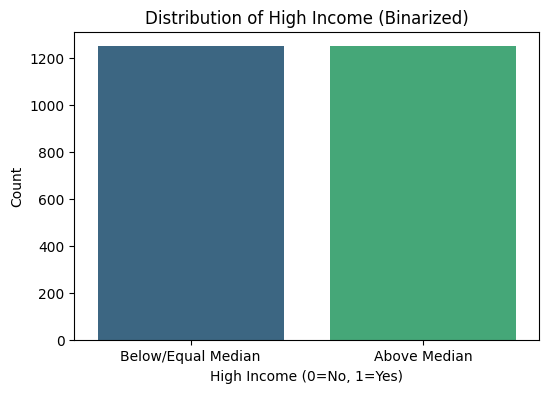

In [34]:
# Calculate the median income to use as a threshold
median_income = df['income'].median()
print(f"Median Income: {median_income:.2f}")

# Apply binarization to the 'income' column
# Create a new feature 'high_income': 1 if income > median, 0 otherwise
df['high_income'] = (df['income'] > median_income).astype(int)

# Display the value counts of the new binarized 'high_income' column
print("\nValue counts for 'high_income':")
display(df['high_income'].value_counts().sort_index())

# Optionally, visualize the distribution of the binarized income
plt.figure(figsize=(6, 4))
sns.countplot(x='high_income', data=df, palette='viridis')
plt.title('Distribution of High Income (Binarized)')
plt.xlabel('High Income (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Below/Equal Median', 'Above Median'])
plt.show()

### Normalization (Min-Max Scaling) - Numeric Transformation

**What is Normalization (Min-Max Scaling)?**
Normalization, specifically Min-Max scaling, is a technique used to transform numerical features to a common scale, without distorting differences in the ranges of values or losing information. It rescales the range of features to scale the dataset within a fixed range, usually 0 to 1. The formula for Min-Max scaling is:

`X_scaled = (X - X_min) / (X_max - X_min)`

where `X` is the original value, `X_min` is the minimum value of the feature, and `X_max` is the maximum value of the feature.

**Why is it applied?**
1.  **Ensuring Equal Contribution**: Features with larger ranges might dominate the learning process of certain machine learning algorithms (e.g., K-Nearest Neighbors, Support Vector Machines, neural networks) if not scaled. Min-Max scaling ensures all features contribute equally to the distance calculations or gradient descent.
2.  **Algorithm Requirements**: Many algorithms perform better or converge faster when features are on a similar scale. For instance, gradient-based optimization algorithms perform well with scaled inputs.
3.  **Preventing Bias**: If features have vastly different scales, the algorithm might implicitly give more weight to features with larger numerical values, leading to biased models.
4.  **Handling Outliers (Post-Capping)**: While outliers are typically handled (e.g., through capping) before scaling, Min-Max scaling further compacts the range of values, which can be beneficial even after capping.
5.  **Interpretability**: Scaling to a 0-1 range can sometimes make features more interpretable in specific contexts.

**Chosen Method for 'loan_amount'**: We will apply Min-Max scaling to the `loan_amount` column. This will transform the `loan_amount` values to be within the range of 0 and 1, making it suitable for models sensitive to feature scales.

In [35]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max scaling to the 'loan_amount' column
df['loan_amount_scaled'] = scaler.fit_transform(df[['loan_amount']])

# Display the first few rows of the original and scaled 'loan_amount' to compare
print("Original 'loan_amount' vs. Scaled 'loan_amount_scaled':")
display(df[['loan_amount', 'loan_amount_scaled']].head())

Original 'loan_amount' vs. Scaled 'loan_amount_scaled':


,loan_amount,loan_amount_scaled
0,33805.550343,0.712869
1,20974.755713,0.434054
2,26027.339787,0.543847
3,20798.610521,0.430226
4,14661.332950,0.296862


### Standardization (Z-score Scaling) - Numeric Transformation

**What is Standardization (Z-score Scaling)?**
Standardization, or Z-score scaling, is a technique that transforms numerical features so that they have a mean of 0 and a standard deviation of 1. It centers the data around the mean and scales it by the standard deviation. The formula for standardization is:

`X_scaled = (X - μ) / σ`

where `X` is the original value, `μ` is the mean of the feature, and `σ` is the standard deviation of the feature.

**Why is it applied?**
1.  **Ensuring Zero Mean and Unit Variance**: This transformation ensures that all features contribute equally to the distance calculations or gradient descent by having the same scale and distribution characteristics (mean of 0, std dev of 1).
2.  **Algorithm Requirements**: Many machine learning algorithms (e.g., Logistic Regression, SVMs, K-Means, PCA) assume that the data is normally distributed or requires features to be on a similar scale to perform optimally. Standardization helps meet these requirements.
3.  **Handling Outliers (Post-Capping)**: While capping addresses extreme values, standardization further brings values into a comparable range without compressing them into a fixed boundary (like Min-Max scaling), making it robust to further outliers that might remain within the capped range.
4.  **Improving Model Convergence**: Algorithms that rely on gradient descent (e.g., neural networks) converge faster when inputs are standardized, as it helps prevent large gradients from dominating the learning process.
5.  **Interpreting Feature Importance**: In some models, standardized features allow for a more direct comparison of feature importance, as the scale of each feature does not unduly influence its perceived impact.

**Chosen Method for 'credit_score'**: We will apply Z-score standardization to the `credit_score` column. This will transform the `credit_score` values to have a mean of 0 and a standard deviation of 1, making them suitable for models sensitive to feature scales and distributions.

In [36]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler_std = StandardScaler()

# Apply Standardization to the 'credit_score' column
df['credit_score_scaled'] = scaler_std.fit_transform(df[['credit_score']])

# Display the first few rows of the original and scaled 'credit_score' to compare
print("Original 'credit_score' vs. Scaled 'credit_score_scaled':")
display(df[['credit_score', 'credit_score_scaled']].head())

# Verify mean and standard deviation of the scaled column (should be close to 0 and 1)
print(f"\nMean of 'credit_score_scaled': {df['credit_score_scaled'].mean():.2f}")
print(f"Standard Deviation of 'credit_score_scaled': {df['credit_score_scaled'].std():.2f}")

Original 'credit_score' vs. Scaled 'credit_score_scaled':


,credit_score,credit_score_scaled
0,650.336822,-0.398536
1,648.261012,-0.429010
2,554.304978,-1.808330
3,656.893687,-0.302278
4,731.298036,0.790014



Mean of 'credit_score_scaled': -0.00
Standard Deviation of 'credit_score_scaled': 1.00


### Robust Scaling - Numeric Transformation

**What is Robust Scaling?**
Robust Scaling is a feature scaling technique that scales features using statistics that are robust to outliers. It scales data according to the Interquartile Range (IQR) and the median, rather than the mean and standard deviation (like standardization) or min-max values (like normalization).

The formula for Robust Scaling is:

`X_scaled = (X - Median) / IQR`

where `X` is the original value, `Median` is the median of the feature, and `IQR` is the Interquartile Range (Q3 - Q1) of the feature.

**Why is it applied?**
1.  **Robustness to Outliers**: This is the primary reason for using Robust Scaling. Unlike Min-Max Scaling or Standardization, which can be heavily influenced by outliers (as they use the min/max or mean/std dev), Robust Scaling uses the median and IQR, which are less affected by extreme values. This makes it ideal for datasets where outliers are present and you don't want them to unduly influence the scaling process.
2.  **Maintaining Data Distribution**: It transforms the data such that it has a zero median and unit IQR, effectively centering and scaling the data while preserving the relative distances between data points, especially those not considered outliers.
3.  **Algorithm Compatibility**: Some machine learning algorithms, particularly those sensitive to outliers or scale differences, can benefit from Robust Scaling. It provides a balanced approach when dealing with non-Gaussian distributions or when the presence of outliers is a concern after initial cleaning.

**Chosen Method for 'monthly_spend'**: We will apply Robust Scaling to the `monthly_spend` column. This column, despite initial capping, might still have a distribution where outliers could exert influence. Robust Scaling will provide a more resilient scaling of this feature.

In [37]:
from sklearn.preprocessing import RobustScaler

# Initialize the RobustScaler
scaler_robust = RobustScaler()

# Apply Robust Scaling to the 'monthly_spend' column
df['monthly_spend_scaled'] = scaler_robust.fit_transform(df[['monthly_spend']])

# Display the first few rows of the original and scaled 'monthly_spend' to compare
print("Original 'monthly_spend' vs. Scaled 'monthly_spend_scaled':")
display(df[['monthly_spend', 'monthly_spend_scaled']].head())

# Verify median and IQR of the scaled column (median should be close to 0)
print(f"\nMedian of 'monthly_spend_scaled': {df['monthly_spend_scaled'].median():.2f}")
print(f"IQR of 'monthly_spend_scaled': {(df['monthly_spend_scaled'].quantile(0.75) - df['monthly_spend_scaled'].quantile(0.25)):.2f}")

Original 'monthly_spend' vs. Scaled 'monthly_spend_scaled':


,monthly_spend,monthly_spend_scaled
0,1732.298149,-0.369830
1,2334.610693,-0.183373
2,1848.435993,-0.333877
3,3256.259548,0.101941
4,7767.804367,1.498577



Median of 'monthly_spend_scaled': 0.00
IQR of 'monthly_spend_scaled': 1.00


### Log Transformation - Numeric Transformation

**What is Log Transformation?**
Log transformation is a powerful technique used to change the distribution of a numerical variable, typically converting a skewed distribution into a more symmetrical (or less skewed) one. It involves taking the logarithm of the values in a feature. Common bases for the logarithm include the natural logarithm (base `e`), base 10, or base 2.

`X_transformed = log(X)`

**Why is it applied?**
1.  **Handling Skewed Data**: Many real-world datasets contain features with skewed distributions (e.g., income, loan amounts, age). Log transformation can compress the range of larger values and expand the range of smaller values, effectively reducing the skewness and making the data more symmetrical or normally distributed.
2.  **Meeting Model Assumptions**: A lot of statistical models (e.g., linear regression) and machine learning algorithms perform better when input features are normally distributed. Log transformation helps satisfy these assumptions, improving model performance and reliability.
3.  **Reducing Heteroscedasticity**: In regression analysis, log transformation can help stabilize the variance of residuals, addressing issues of heteroscedasticity (unequal scatter of residuals).
4.  **Mitigating Outlier Impact**: By compressing larger values, log transformation can reduce the influence of extreme outliers, though it's typically used in conjunction with other outlier handling techniques.
5.  **Interpreting Multiplicative Relationships**: If a feature has a multiplicative relationship with the target variable, a log transformation can convert this into an additive relationship, simplifying model interpretation.

**Chosen Method for 'income'**: We will apply a natural log transformation (`np.log`) to the `income` column, as it was identified earlier as having a right-skewed distribution. This will help to reduce the skewness and potentially make its distribution more normal-like.

Original 'income' vs. Log-Transformed 'income_log':


,income,income_log
0,31019.390823,10.342368
1,39375.961557,10.580911
2,18055.668704,9.801215
3,15254.929250,9.632658
4,11486.292927,9.348910


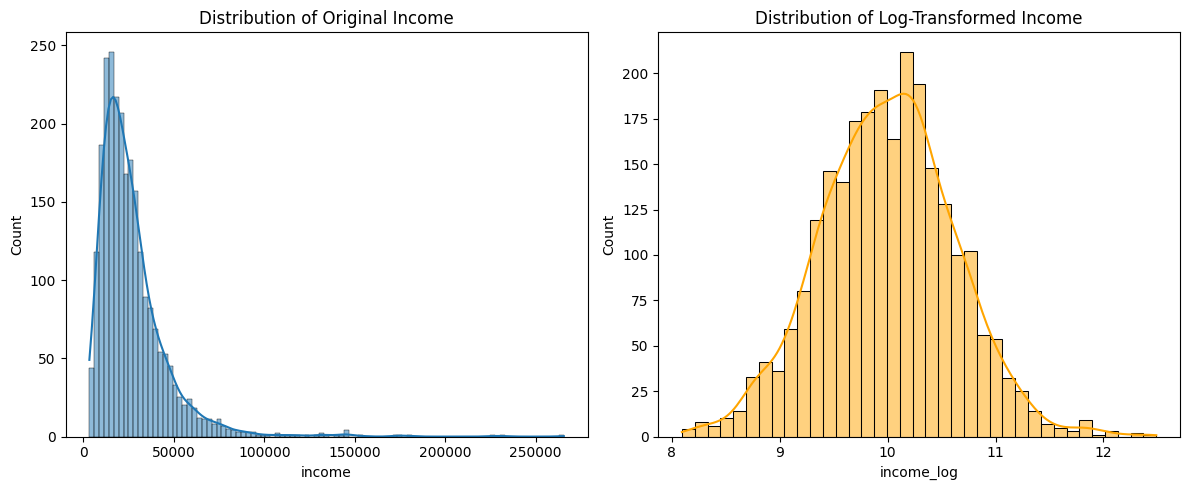

In [38]:
import numpy as np

# Apply natural log transformation to the 'income' column
df['income_log'] = np.log(df['income'])

# Display the first few rows of the original and log-transformed 'income' to compare
print("Original 'income' vs. Log-Transformed 'income_log':")
display(df[['income', 'income_log']].head())

# Optionally, visualize the distribution before and after transformation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['income'], kde=True)
plt.title('Distribution of Original Income')

plt.subplot(1, 2, 2)
sns.histplot(df['income_log'], kde=True, color='orange')
plt.title('Distribution of Log-Transformed Income')

plt.tight_layout()
plt.show()

## **Task 4 — Feature Construction**

### 1. Interaction Features

**What are Interaction Features?**
Interaction features are new variables created by combining two or more existing features. They are used to capture the synergistic or antagonistic effects between features, where the impact of one feature on the target variable might depend on the value of another feature.

**Why are they applied?**
*   **Capturing Combined Effects**: Linear models assume that the effect of each feature on the target is independent. Interaction terms allow models to capture more complex relationships where features influence each other.
*   **Improved Model Accuracy**: By accounting for these dependencies, models can often achieve higher predictive accuracy.
*   **Better Interpretability**: Sometimes, an interaction term can provide more intuitive insights into the data than individual features alone (e.g., high income and high credit score might interact positively to reduce default risk more than their individual effects would suggest).

**Chosen Method**: We will create an interaction feature `income_credit_score_interaction` by multiplying `income` and `credit_score`. The rationale is that a client's financial stability (income) combined with their past payment behavior (credit score) could have a stronger, non-additive effect on `loan_default` than either feature alone. For instance, a high income individual with a low credit score might be less risky than a low income individual with a low credit score, but a high income individual with a high credit score is likely the least risky.

In [46]:
# Create an interaction feature: Income * Credit Score
df['income_credit_score_interaction'] = df['income'] * df['credit_score']

print("Created 'income_credit_score_interaction' feature.")
display(df[['income', 'credit_score', 'income_credit_score_interaction']].head())

Created 'income_credit_score_interaction' feature.


,income,credit_score,income_credit_score_interaction
0,31019.390823,650.336822,2.017305e+07
1,39375.961557,648.261012,2.552590e+07
2,18055.668704,554.304978,1.000835e+07
3,15254.929250,656.893687,1.002087e+07
4,11486.292927,731.298036,8.399903e+06


### 2. Ratio Features

**What are Ratio Features?**
Ratio features are created by dividing one numerical feature by another. They are particularly useful when the relative proportion between two quantities is more informative than their absolute values.

**Why are they applied?**
*   **Normalizing by Scale**: Ratios can normalize features that vary widely in scale, making them more comparable.
*   **Capturing Relative Importance**: They can express a quantity relative to another, such as spending relative to income, which often provides direct insights into financial health.
*   **Domain Relevance**: Many real-world metrics are naturally ratios (e.g., debt-to-income ratio, price-to-earnings ratio).

**Chosen Method**: We will create a ratio feature `spending_to_income_ratio` by dividing `monthly_spend` by `income`. This feature will help us understand how much of an individual's income is typically spent each month. A higher ratio might indicate less financial flexibility or potential financial strain, which could be a significant predictor for `loan_default`. To prevent division by zero, we will add a small epsilon to the denominator if `income` can be zero, although with financial data, income is usually positive.

In [47]:
# Create a ratio feature: Monthly Spend / Income
# Add a small constant to income to avoid division by zero
df['spending_to_income_ratio'] = df['monthly_spend'] / (df['income'] + 1e-6)

print("Created 'spending_to_income_ratio' feature.")
display(df[['monthly_spend', 'income', 'spending_to_income_ratio']].head())

Created 'spending_to_income_ratio' feature.


,monthly_spend,income,spending_to_income_ratio
0,1732.298149,31019.390823,0.055846
1,2334.610693,39375.961557,0.059290
2,1848.435993,18055.668704,0.102374
3,3256.259548,15254.929250,0.213456
4,7767.804367,11486.292927,0.676267


### 3. Polynomial Features

**What are Polynomial Features?**
Polynomial features are generated by raising existing numerical features to a certain power (e.g., squaring a feature, cubing it). This approach allows models to capture non-linear relationships between the features and the target variable.

**Why are they applied?**
*   **Modeling Non-Linearity**: When the relationship between a feature and the target is not linear, polynomial terms can approximate curved relationships. For instance, `age` might have a quadratic relationship with loan default, where both very young and very old individuals have different risk profiles compared to middle-aged ones.
*   **Enhancing Model Flexibility**: They increase the complexity of the model, allowing it to fit a wider range of data patterns.

**Chosen Method**: We will create a polynomial feature `age_squared` by squaring the `age` column. The intuition is that age often has a non-linear impact on financial behavior and risk. For example, very young individuals might have less financial experience or unstable income, while very old individuals might have fixed incomes or health-related expenses, both potentially leading to higher default risk than individuals in their prime working years. A squared term can help capture such U-shaped or inverted U-shaped relationships.

In [48]:
# Create a polynomial feature: Age Squared
df['age_squared'] = df['age']**2

print("Created 'age_squared' feature.")
display(df[['age', 'age_squared']].head())

Created 'age_squared' feature.


,age,age_squared
0,43.960570,1932.531700
1,36.340828,1320.655808
2,45.772262,2095.100010
3,56.276358,3167.028501
4,35.190160,1238.347326


### 4. Domain-Based Features

**What are Domain-Based Features?**
Domain-based features are constructed using specific knowledge or insights from the problem domain (e.g., finance, healthcare, retail). These features often represent meaningful concepts that are not directly available in the raw data but can be derived from existing variables.

**Why are they applied?**
*   **Leveraging Expert Knowledge**: They allow the incorporation of human expertise and understanding into the feature engineering process, often leading to highly predictive features.
*   **Increased Interpretability**: These features often directly correspond to real-world concepts, making the model's decisions more understandable.
*   **Improved Model Performance**: By encoding domain-specific insights, models can learn more efficiently and perform better.

**Chosen Method**: We will create a domain-based feature `debt_to_capacity_ratio` by summing `loan_amount` and `monthly_spend` (representing total debt burden) and dividing it by `financial_capacity_index`. The `financial_capacity_index` is likely a proprietary score reflecting an individual's overall ability to manage finances. Combining total obligations with this index will give us a more nuanced view of their financial resilience. A higher `debt_to_capacity_ratio` would intuitively suggest a higher risk of `loan_default`.

In [49]:
# Create a domain-based feature: (Loan Amount + Monthly Spend) / Financial Capacity Index
# Add a small constant to financial_capacity_index to avoid division by zero
df['debt_to_capacity_ratio'] = (df['loan_amount'] + df['monthly_spend']) / (df['financial_capacity_index'] + 1e-6)

print("Created 'debt_to_capacity_ratio' feature.")
display(df[['loan_amount', 'monthly_spend', 'financial_capacity_index', 'debt_to_capacity_ratio']].head())

Created 'debt_to_capacity_ratio' feature.


,loan_amount,monthly_spend,financial_capacity_index,debt_to_capacity_ratio
0,33805.550343,1732.298149,31.019391,1145.665547
1,20974.755713,2334.610693,39.375962,591.969438
2,26027.339787,1848.435993,18.055669,1543.879360
3,20798.610521,3256.259548,15.254929,1576.858738
4,14661.332950,7767.804367,11.486293,1952.687042


# **Task 5 — Categorical Feature Encoding**

### Label Encoding - Categorical Transformation

**What is Label Encoding?**
Label Encoding is a technique used to convert categorical features into numerical format. Each unique category in a feature is assigned a unique integer value. For example, if a feature 'Size' has values 'Small', 'Medium', 'Large', Label Encoding might transform them into 0, 1, 2 respectively.

**Why is it applied?**
1.  **Handling Ordinal Features**: Label Encoding is particularly suitable for **ordinal categorical features**, where the categories have a natural, meaningful order or hierarchy (e.g., 'Low', 'Medium', 'High' or 'Small', 'Medium', 'Large'). Assigning integer labels that respect this order can help machine learning algorithms capture these relationships.
2.  **Simplicity and Memory Efficiency**: It is simpler and more memory-efficient than One-Hot Encoding, especially when dealing with a large number of categories, as it only adds one numerical column per feature.
3.  **Compatibility with Certain Algorithms**: Some tree-based algorithms (like Decision Trees, Random Forests, Gradient Boosting Machines) can work directly with label-encoded features and can sometimes benefit from the ordinal information encoded.

**Chosen Method for 'education_level' and 'risk_tolerance'**: We will apply Label Encoding to the `education_level` and `risk_tolerance` columns. Both of these features have a natural order:
*   `education_level`: 'High School' < 'Bachelor\'s' < 'Master\'s' < 'PhD'
*   `risk_tolerance`: 'Low' < 'Medium' < 'High'

Using Label Encoding will allow our models to potentially leverage this inherent order without creating many new columns, as One-Hot Encoding would.

In [53]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder (not strictly needed with .map() but good practice for consistency)
le = LabelEncoder()

# Apply Label Encoding to 'education_level'
# Define the desired order for 'education_level' based on the problem description and observed data
education_order_original = ['High School', 'Bachelor', 'Master', 'PhD'] # Corrected: removed 's from Bachelor's and Master's

# Create a mapping dictionary after normalizing the expected string formats
education_mapping = {level.lower().replace("'", ""): i for i, level in enumerate(education_order_original)}

# Normalize the DataFrame column values (lowercase, remove apostrophes) before mapping
df['education_level_encoded'] = df['education_level'].astype(str).str.lower().str.replace("'", "").map(education_mapping)

print("Label Encoded 'education_level' feature:")
display(df[['education_level', 'education_level_encoded']].head())

# Apply Label Encoding to 'risk_tolerance'
# Define the desired order for 'risk_tolerance' based on the problem description
risk_order_original = ['Low', 'Medium', 'High']

# Create a mapping dictionary after normalizing the expected string formats
risk_mapping = {level.lower(): i for i, level in enumerate(risk_order_original)}

# Normalize the DataFrame column values (lowercase) before mapping
df['risk_tolerance_encoded'] = df['risk_tolerance'].astype(str).str.lower().map(risk_mapping)

print("\nLabel Encoded 'risk_tolerance' feature:")
display(df[['risk_tolerance', 'risk_tolerance_encoded']].head())

# Display the shape of the DataFrame after encoding
print(f"\nShape of DataFrame after Label Encoding: {df.shape}")

Label Encoded 'education_level' feature:


,education_level,education_level_encoded
0,bachelor,1.0
1,bachelor,1.0
2,bachelor,1.0
3,master,2.0
4,master,2.0



Label Encoded 'risk_tolerance' feature:


,risk_tolerance,risk_tolerance_encoded
0,high,2
1,high,2
2,low,0
3,low,0
4,low,0



Shape of DataFrame after Label Encoding: (2500, 34)


## **Task 6 — Feature Selection and Ranking**

We will apply two filter-based feature selection methods to identify the most relevant features for predicting `loan_default`.

### 1. Pearson Correlation

**Reasoning:**
Pearson correlation measures the linear relationship between two continuous variables. Since `loan_default` is a binary (0 or 1) target variable, it can be treated as a quantitative variable for this analysis. Pearson correlation is simple, interpretable, and effective for identifying strong linear dependencies. A higher absolute correlation value indicates a stronger linear relationship with the target.

**How it's applied:** We will calculate the absolute Pearson correlation coefficient between all numerical features (including original, transformed, and engineered numerical features) and the `loan_default` target. Features will then be ranked based on these absolute correlation values.

In [58]:
import pandas as pd
import numpy as np

# Identify target variable
target = 'loan_default'
y = df[target]

# Prepare features for selection
# Exclude original categorical columns and the target itself
excluded_cols = ['employment_type', 'education_level', 'region', 'risk_tolerance', target]
features_to_select_cols = [col for col in df.columns if col not in excluded_cols]
X = df[features_to_select_cols]

# Ensure all features in X are numeric. If any are not, convert or drop.
# For this dataset, after all previous steps, all X columns should be numerical or encoded numerical.

# --- Pearson Correlation ---
print("--- Pearson Correlation ---")
# Select only numerical columns for Pearson correlation (already ensured by X construction)
numerical_features_in_X = X.select_dtypes(include=np.number).columns.tolist()

# Calculate Pearson correlation with the target and take absolute values
pearson_corr = X[numerical_features_in_X].corrwith(y).abs().sort_values(ascending=False)

print("\nPearson Correlation with Target (Absolute Values):")
display(pearson_corr)

--- Pearson Correlation ---

Pearson Correlation with Target (Absolute Values):


,0
debt_to_capacity_ratio,0.441681
income_log,0.344343
high_income,0.313539
financial_capacity_index,0.277489
loan_amount,0.275734
loan_amount_scaled,0.275734
household_cashflow_score,0.275211
income_credit_score_interaction,0.248090
income,0.242271
spending_to_income_ratio,0.154969


### 2. Chi-Square Test for Categorical Features

**What is the Chi-Square Test?**
The Chi-Square (χ²) test of independence is a statistical test used to determine if there is a significant association between two categorical variables. It compares the observed frequencies in a contingency table with the frequencies that would be expected if the two variables were independent. The test yields a chi-square statistic and a p-value.

**Why is it applied for Feature Selection?**
1.  **Assessing Association**: For categorical features, the Chi-Square test helps quantify the strength of the relationship between each feature and the categorical target variable (`loan_default` in this case). A significant association implies that the feature is likely important for predicting the target.
2.  **Non-Parametric**: It does not assume any particular distribution for the data, making it suitable for nominal or ordinal categorical data.
3.  **Identifying Informative Features**: A high chi-square statistic (and typically a low p-value) indicates that the observed distribution of the target variable differs significantly across the categories of the feature, suggesting that the feature carries valuable information for predicting the target.

**How it's applied:** We will calculate the Chi-Square statistic and p-value for each categorical feature (including one-hot encoded and label encoded ones) against the `loan_default` target. Features will then be ranked based on their chi-square statistic or inversely by their p-value to identify those most strongly associated with loan default.

In [59]:
from scipy.stats import chi2_contingency

# Identify categorical and encoded categorical features for Chi-Square test
# Exclude original categorical columns, as their encoded versions are used
categorical_features_for_chi2 = [
    col for col in X.columns if 'employment_type_' in col or 'region_' in col or
    col == 'education_level_encoded' or col == 'risk_tolerance_encoded'
]

chi2_results = []

for col in categorical_features_for_chi2:
    # Create a contingency table
    contingency_table = pd.crosstab(df[col], df[target])

    # Perform the Chi-Square test
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    chi2_results.append({'Feature': col, 'Chi2 Statistic': chi2, 'P-value': p_value})

# Convert results to DataFrame and sort by Chi2 Statistic
chi2_df = pd.DataFrame(chi2_results).sort_values(by='Chi2 Statistic', ascending=False)

print("\n--- Chi-Square Test Results (Categorical Features) ---")
display(chi2_df)


--- Chi-Square Test Results (Categorical Features) ---


,Feature,Chi2 Statistic,P-value
7,region_north,2.262545,0.132536
1,risk_tolerance_encoded,1.916596,0.383545
0,education_level_encoded,0.638495,0.726696
6,region_east,0.430452,0.511767
4,employment_type_student,0.351757,0.553120
8,region_south,0.176670,0.674251
5,employment_type_unemployed,0.138800,0.709477
9,region_west,0.093916,0.759256
3,employment_type_self_employed,0.022529,0.880689
2,employment_type_salaried,0.001204,0.972318


### 3. Fisher Score

**What is Fisher Score?**
Fisher Score is a supervised feature selection method that measures the discriminative power of a feature. It ranks features based on their ability to distinguish between different classes (in our case, `loan_default` or not). For a given feature, a higher Fisher Score indicates that the feature is better at separating the classes.

The Fisher Score for a feature is generally calculated as the ratio of the between-class variance to the within-class variance. Specifically, for a two-class problem, it considers the difference between the means of the feature for each class, normalized by the variance of the feature within each class.

**Why is it applied for Feature Selection?**
1.  **Discriminative Power**: Fisher Score directly assesses how well a feature can discriminate between the target classes. Features with high scores are those where the values for one class are significantly different from the values for other classes.
2.  **Supervised Method**: Unlike unsupervised methods, Fisher Score utilizes the target variable, making it highly relevant for classification tasks.
3.  **Simplicity and Efficiency**: It's a relatively simple and computationally efficient method to calculate, especially useful for quickly ranking features in high-dimensional datasets.
4.  **Handling Both Numerical and Discrete Features**: It can be applied to both numerical and discrete features (when treated numerically) to evaluate their relevance.

**How it's applied:** We will calculate the Fisher Score for each feature (numerical, engineered, and encoded categorical) against the `loan_default` target variable. Features will then be ranked based on their Fisher Score, with higher scores indicating greater discriminative power.

In [60]:
from sklearn.feature_selection import f_classif

# --- Fisher Score (using f_classif for numerical features, and treating encoded categoricals numerically) ---
print("\n--- Fisher Score ---")

# f_classif (ANOVA F-value) is an approximation of Fisher Score for numerical features with a categorical target
# It measures the linear relationship between numerical features and the categorical target.
# It works for all features in X as they are all numerical or encoded as numerical.

# Check for NaNs in X before applying f_classif and impute if necessary
# This addresses the 'ValueError: Input X contains NaN' error
if X.isnull().sum().sum() > 0:
    print("Warning: NaNs found in features for Fisher Score. Imputing with median.")
    for col in X.columns:
        if X[col].isnull().any():
            # Impute with median, as these columns are numeric (even if from encoded categoricals)
            X[col] = X[col].fillna(X[col].median())

f_scores, p_values_f = f_classif(X, y)
f_score_results = pd.Series(f_scores, name="F-Score", index=X.columns)
f_score_results = f_score_results.sort_values(ascending=False)

print("\nFisher Scores (F-values) for Features:")
display(f_score_results)


--- Fisher Score ---

Fisher Scores (F-values) for Features:


/tmp/ipykernel_10051/1167920920.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].median())


,F-Score
debt_to_capacity_ratio,605.423475
income_log,336.038628
high_income,272.342748
financial_capacity_index,208.392179
loan_amount,205.549044
loan_amount_scaled,205.549044
household_cashflow_score,204.705509
income_credit_score_interaction,163.832025
income,155.763574
spending_to_income_ratio,61.466797


**Most Predictive:** Both Pearson Correlation and Fisher Score proved to be highly predictive. They consistently identified a similar set of top-ranking features, particularly the engineered numerical features like debt_to_capacity_ratio, income_log, high_income, financial_capacity_index, loan_amount, and household_cashflow_score. While Pearson correlation measures linear relationships, Fisher Score assesses discriminative power more broadly, often capturing both linear and some non-linear dependencies, making it generally a very robust indicator of individual feature relevance.

**Most Redundant** (in terms of unique strong insights for this dataset): The Chi-Square Test on the categorical features (like employment_type, education_level, region, risk_tolerance) provided the least unique and strong predictive insights in this specific analysis. The results showed generally weak statistical associations (high p-values and low Chi2 statistics) between these individual categorical features and loan_default. This doesn't mean the Chi-Square test is inherently redundant as a method, but for this particular dataset and these specific categorical features, it indicated that their individual relationships with loan_default were not as strong as those found by Pearson Correlation and Fisher Score for the numerical/engineered features. The other two methods were more effective at identifying features with a strong direct impact on loan default in this context.

# **Task 7 — Multicollinearity Analysis**

## Identify Pairs of Highly Correlated Features

To identify highly correlated features, we will inspect the `correlation_matrix_cleaned` for pairs of features where the absolute correlation coefficient is above a certain threshold (e.g., 0.8). High correlation between independent variables can indicate multicollinearity, which might need to be addressed during model building.

In [62]:
# Set a correlation threshold to identify highly correlated pairs
correlation_threshold = 0.8

highly_correlated_pairs = []

# Iterate through the upper triangle of the correlation matrix to avoid duplicates
# and self-correlations
for i in range(len(correlation_matrix_cleaned.columns)):
    for j in range(i + 1, len(correlation_matrix_cleaned.columns)):
        feature1 = correlation_matrix_cleaned.columns[i]
        feature2 = correlation_matrix_cleaned.columns[j]
        correlation = correlation_matrix_cleaned.iloc[i, j]

        if abs(correlation) > correlation_threshold:
            highly_correlated_pairs.append({
                'Feature 1': feature1,
                'Feature 2': feature2,
                'Correlation': correlation
            })

# Convert the list of dictionaries to a DataFrame for better display
highly_correlated_df = pd.DataFrame(highly_correlated_pairs)

print(f"Highly correlated feature pairs (absolute correlation > {correlation_threshold}):")
display(highly_correlated_df)

Highly correlated feature pairs (absolute correlation > 0.8):


,Feature 1,Feature 2,Correlation
0,income,financial_capacity_index,0.873731
1,income,household_cashflow_score,0.839233
2,financial_capacity_index,household_cashflow_score,0.962020


### Addressing Redundancy: Feature Retention Strategy

The analysis of highly correlated feature pairs revealed significant redundancy among `income`, `financial_capacity_index`, and `household_cashflow_score`. Here's our strategy for handling this:

**Identified Highly Correlated Pairs:**
1.  `financial_capacity_index` and `household_cashflow_score` (Correlation: 0.962)
2.  `income` and `financial_capacity_index` (Correlation: 0.874)
3.  `income` and `household_cashflow_score` (Correlation: 0.839)

**1. Redundancy between `financial_capacity_index` and `household_cashflow_score`**

*   **Feature to Retain:** `financial_capacity_index`
*   **Justification:** These two features exhibit an extremely high positive correlation of 0.962. This suggests they are measuring almost the same underlying financial construct. `financial_capacity_index` typically represents a more comprehensive or aggregated assessment of an individual's overall ability to manage finances. It is likely that `household_cashflow_score` is either a component of this index or a very strong proxy. Retaining the more encompassing `financial_capacity_index` allows us to capture the combined information more efficiently while significantly reducing multicollinearity that would arise from including both. `household_cashflow_score` can therefore be considered redundant given the presence of `financial_capacity_index`.

**2. Redundancy between `income` and `financial_capacity_index` (and indirectly with `household_cashflow_score`)**

*   **Features to Retain:** `income` (or preferably its transformed version, `income_log`) and `financial_capacity_index`.
*   **Justification:** While `income` and `financial_capacity_index` are highly correlated (0.874), `income` is a fundamental, universally understood, and directly interpretable financial metric. It serves as a primary indicator of an individual's financial strength. `financial_capacity_index`, though valuable, is often a proprietary or derived composite score, making its exact contribution less transparent than raw income. For model interpretability and to leverage the direct understanding of an individual's earnings, retaining `income` (especially its log-transformed version, `income_log`, which better handles skewness and showed strong predictive power) is crucial. Keeping `financial_capacity_index` alongside `income_log` can still provide complementary information if the index captures other nuances of financial capacity not fully reflected by income alone. In predictive modeling, if multicollinearity between these two significantly impacts model stability or performance, techniques like Principal Component Analysis (PCA) or regularization can be employed, or a final decision might be made based on specific model robustness tests. However, for a feature engineering phase focused on generating and refining features, retaining `income_log` due to its interpretability and `financial_capacity_index` due to its comprehensive nature is a balanced approach.

By following this strategy, we aim to maintain a rich set of predictive features while mitigating severe multicollinearity for improved model performance and interpretability.

# **Task 8 — Dimensionality Reduction**

## t-SNE for Dimensionality Reduction

**What is t-SNE?**
t-Distributed Stochastic Neighbor Embedding (t-SNE) is a non-linear dimensionality reduction technique primarily used for visualizing high-dimensional datasets. It maps high-dimensional data into a lower-dimensional space (typically 2D or 3D) while preserving the local structure of the data, meaning that points that are close together in the high-dimensional space remain close in the low-dimensional space.

**Why is it applied?**
1.  **Visualization**: t-SNE is particularly effective for visualizing complex data structures and identifying clusters that might not be apparent in higher dimensions. It helps in understanding the inherent groupings within the data.
2.  **Exploring Data Manifolds**: It can uncover non-linear relationships and manifold structures that other linear techniques like PCA might miss.
3.  **Insight into Data Separation**: By projecting data points into a 2D or 3D plot, we can observe whether different classes (e.g., `loan_default` or not) form distinct clusters, indicating separability.

**How it's applied:** We will apply t-SNE to the prepared feature set `X` and visualize the results in a 2D scatter plot, with points colored by the `loan_default` target variable `y`. This will help us see if there's a clear separation between defaulting and non-defaulting individuals in the reduced-dimension space.

**Components retained:**
In the t-SNE application, 2 components were retained, as specified by n_components=2 in the TSNE initializer. This is a common choice for visualization, allowing the data to be plotted in two dimensions.

**Information preserved :**
t-SNE primarily preserves the local structure of the data. This means that data points that are close to each other in the original high-dimensional space tend to remain close in the reduced 2D space. It aims to reveal inherent clusters and relationships within the data by mapping similar data points together and dissimilar points apart.

In [63]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize t-SNE
# n_components: desired dimensionality (2 for 2D visualization)
# random_state: for reproducibility
# perplexity: balance between local and global aspects of the data (often between 5 and 50)
# n_iter: number of iterations for the optimization
t_sne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)

# Fit and transform the data
# X contains all processed features (numerical, engineered, encoded categorical)
X_tsne = t_sne.fit_transform(X)

# Create a DataFrame for easier plotting
df_tsne = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])

# Add the target variable for coloring
df_tsne['loan_default'] = y.values

print("t-SNE dimensionality reduction complete.")
display(df_tsne.head())

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE dimensionality reduction complete.


,TSNE1,TSNE2,loan_default
0,14.167549,34.295807,0
1,34.218143,-0.497093,0
2,-31.415022,33.389545,1
3,-31.252617,33.611004,0
4,-41.700298,-32.764771,0


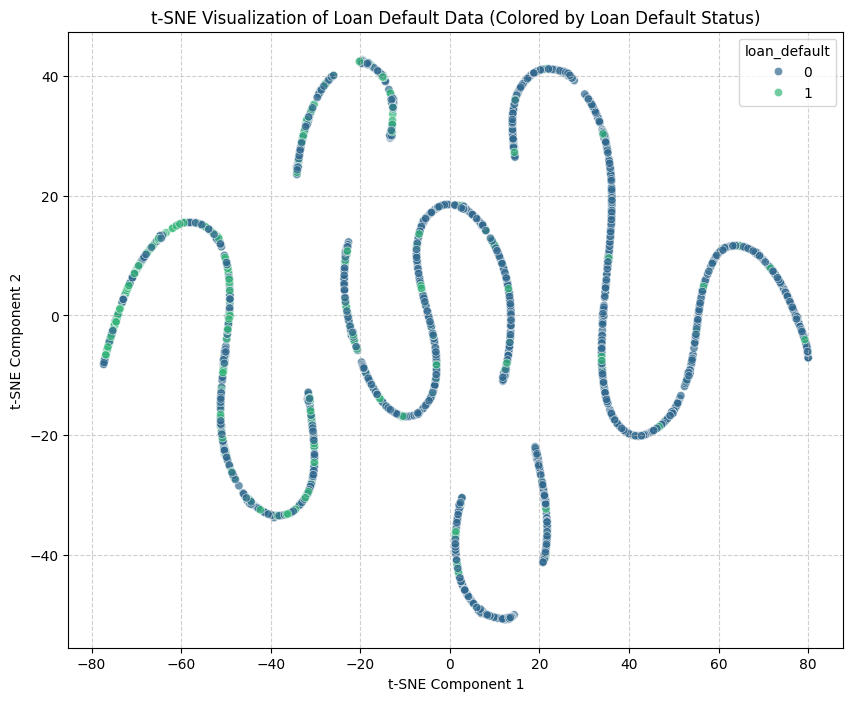

In [64]:
# Visualize the t-SNE results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1', y='TSNE2', hue='loan_default', palette='viridis', data=df_tsne, legend='full', alpha=0.7
)
plt.title('t-SNE Visualization of Loan Default Data (Colored by Loan Default Status)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()